In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit

from pydaqmx_helper.adc import ADC
from pydaqmx_helper.dac import DAC

## initialising the NI

In [2]:
# DAQ interface initialisation
myADC = ADC()
myDAC = DAC(0)
# https://physicslabs.ucd.ie/documentation/dacq/data_aq_tips/

myADC.addChannels([0,1,2,3,4,5,6,7], # the 8 channels we have to initially take across
                  ADC_mode='DAQmx_Val_RSE') # single-ended mode
# https://physicslabs.ucd.ie/documentation/dacq/ni_usb_6000/


Activated Channel 0
Activated Channel 1
Activated Channel 2
Activated Channel 3
Activated Channel 4
Activated Channel 5
Activated Channel 6
Activated Channel 7


In [123]:
"""myDAC.writeVoltage(0)
test = myADC.sampleVoltages(1)
test"""

'myDAC.writeVoltage(0)\ntest = myADC.sampleVoltages(1)\ntest'

In [3]:
def thermocouple_16loop():
    voltages=np.zeros(16) # array of 0's shape 16 (for the 16 thermocouples)

    # reading channels 1-8 (switches at 0V)
    myDAC.writeVoltage(0)
    time.sleep(0.05)
    set1=myADC.sampleVoltages(1)
    for i in range(8):
        voltages[i]=set1[i][0]

    # reading channels 9-16 (switches at 5V)
    myDAC.writeVoltage(5)
    time.sleep(0.05)
    set2=myADC.sampleVoltages(1)
    for i in range(8):
        voltages[i+8]=set2[i][0]

    myDAC.writeVoltage(0) #resetting loop back to 0 for next measurements
    return voltages

In [129]:
test = thermocouple_16loop()
print(len(test))
print(test)

16
[0.03684877 0.02670395 0.03578481 0.03645758 0.01545969 0.02490969
 0.02540259 0.01472598 0.02663277 0.01649024 0.02555703 0.00581228
 0.21975281 0.21898897 0.21951473 0.83196913]


In [135]:
test2 = thermocouple_16loop()
print(test2)

[-0.05509524 -0.05500573 -0.04603742 -0.05547832 -0.07647222 -0.0772373
 -0.05632883 -0.07721388 -0.07552724 -0.08564685 -0.06649298 -0.07590853
 -0.06625756 -0.0670226  -0.05632883 -0.06699834]


## volt to temp reading conversion

### readings for volt to temp

im going to now take the thermometer readings of the hot water and the room temp water before i submerge them to take the voltages

room temp water is from the tap and for the hot water i just boiled it in a kettle

In [142]:
Troom = np.average([20.1, 20.2, 20.3])
Vroom = thermocouple_16loop()

print(Troom)
print(Vroom)

20.2
[-0.07552724 -0.08564685 -0.07672076 -0.08612363 -0.10711619 -0.1078814
 -0.08697812 -0.1078605  -0.10617525 -0.11628798 -0.09717631 -0.11676893
 -0.09690153 -0.0976667  -0.08697812 -0.1078605 ]


In [4]:
Troom = 20.2
Vroom = np.array([-0.07552724, -0.08564685, -0.07672076, -0.08612363, -0.10711619, -0.1078814,
 -0.08697812, -0.1078605,  -0.10617525, -0.11628798, -0.09717631, -0.11676893,
 -0.09690153, -0.0976667,  -0.08697812, -0.1078605 ])

In [144]:
Thot = 76.5
Vhot = thermocouple_16loop()

print(Thot)
print(Vhot)

76.5
[1.68162501 1.66089737 1.69268489 1.68108879 1.67023401 1.66947625
 1.68046395 1.66964336 1.630545   1.64046995 1.641546   1.64022838
 1.68044866 1.67969095 1.68046395 1.69007444]


In [5]:
Thot = 76.5
Vhot = np.array([1.68162501, 1.66089737, 1.69268489, 1.68108879, 1.67023401,1.66947625,
 1.68046395, 1.66964336, 1.630545,   1.64046995, 1.641546,   1.64022838,
 1.68044866, 1.67969095, 1.68046395, 1.69007444])

In [145]:
Thot1 = 66.3
Vhot1 = thermocouple_16loop()

print(Thot1)
print(Vhot1)

66.3
[1.37514497 1.36469981 1.37562376 1.38485087 1.38422363 1.36303528
 1.39440396 1.36317718 1.34449696 1.34427239 1.35516821 1.33377536
 1.38422363 1.38346468 1.39440396 1.3938238 ]


In [6]:
Thot1 = 66.3
Vhot1 = np.array([1.37514497, 1.36469981, 1.37562376, 1.38485087, 1.38422363, 1.36303528,
 1.39440396, 1.36317718, 1.34449696, 1.34427239, 1.35516821, 1.33377536,
 1.38422363, 1.38346468, 1.39440396, 1.3938238 ])

In [146]:
Thot2 = 56.3
Vhot2 = thermocouple_16loop()

print(Thot2)
print(Vhot2)

56.3
[1.04823292 1.02764742 1.05856264 1.03753745 1.03692532 1.02595021
 1.05726183 1.03627992 1.02780092 1.01743371 1.0278793  1.01710724
 1.03692532 1.0361649  1.05726183 1.04649546]


In [7]:
Thot2 = 56.3
Vhot2 = np.array([1.04823292, 1.02764742, 1.05856264, 1.03753745, 1.03692532, 1.02595021,
 1.05726183, 1.03627992, 1.02780092, 1.01743371, 1.0278793,  1.01710724,
 1.03692532, 1.0361649,  1.05726183, 1.04649546])

In [147]:
Thot3 = 45.8
Vhot3 = thermocouple_16loop()

print(Thot3)
print(Vhot3)

45.8
[0.70088887 0.69059502 0.71081817 0.70043912 0.67941234 0.67865043
 0.70990328 0.68895158 0.67024086 0.6599539  0.68013484 0.66979382
 0.69984166 0.69907983 0.70990328 0.70938266]


In [8]:
Thot3 = 45.8
Vhot3 = np.array([0.70088887, 0.69059502, 0.71081817, 0.70043912, 0.67941234, 0.67865043,
 0.70990328, 0.68895158, 0.67024086, 0.6599539,  0.68013484, 0.66979382,
 0.69984166, 0.69907983, 0.70990328, 0.70938266])

In [148]:
Thot4 = 36.5
Vhot4 = thermocouple_16loop()

print(Thot4)
print(Vhot4)

36.5
[0.40462483 0.40461117 0.42444038 0.41441631 0.38318731 0.38242416
 0.41362686 0.39270094 0.38419282 0.37397005 0.38352927 0.3735559
 0.39340197 0.39263886 0.41362686 0.39270094]


In [9]:
Thot4 = 36.5
Vhot4 = np.array([0.40462483, 0.40461117, 0.42444038, 0.41441631, 0.38318731, 0.38242416,
 0.41362686, 0.39270094, 0.38419282, 0.37397005, 0.38352927, 0.3735559,
 0.39340197, 0.39263886, 0.41362686, 0.39270094])

In [149]:
Thot5 = 26.7
Vhot5 = thermocouple_16loop()

print(Thot5)
print(Vhot5)

26.7
[0.07771278 0.06755878 0.07669592 0.07731798 0.04610365 0.04533909
 0.06626831 0.0453726  0.04706477 0.03691765 0.05624036 0.03645758
 0.06653297 0.06576849 0.08670116 0.06580368]


In [10]:
Thot5 = 26.7
Vhot5 = np.array([0.07771278, 0.06755878, 0.07669592, 0.07731798, 0.04610365, 0.04533909,
 0.06626831, 0.0453726,  0.04706477, 0.03691765, 0.05624036, 0.03645758,
 0.06653297, 0.06576849, 0.08670116, 0.06580368])

### actually getting the conversion/calibration

In [11]:
temps=np.array([Troom, Thot, Thot1, Thot2, Thot3, Thot4, Thot5])
volts=np.stack([Vroom, Vhot, Vhot1, Vhot2, Vhot3, Vhot4, Vhot5]) # need to stack the (7,16) matrices

slopes=np.zeros(16)
intercs=np.zeros(16)

for i in range(16):
    vs=volts[:,i]
    m,c=np.polyfit(vs,temps,1)
    slopes[i]=m
    intercs[i]=c

print('Slopes: ', slopes)
print('Intercepts: ', intercs)

Slopes:  [31.42006064 31.62191021 31.31959221 31.32259477 30.856483   31.05096277
 31.08620461 31.05738444 31.65082971 31.35100596 31.61248281 31.43223392
 31.06083663 31.06070631 31.25421674 30.74265148]
Intercepts:  [23.50236895 23.72401867 23.35614532 23.58915718 24.44983651 24.46792385
 23.65218157 24.32454218 24.30055665 24.70021979 24.10594721 24.6542884
 23.98387968 24.00763376 23.43530331 24.10467316]


In [12]:
def volt_to_C(v):
    temp_C=(v*slopes)+intercs
    return temp_C

def volt_to_K(v):
    temp_C=(v*slopes)+intercs
    return temp_C + 273.5

In [163]:
print(volt_to_C(Vhot))
print(volt_to_K(Vhot))

#testing

[76.33912879 76.24476615 76.37034582 76.24522015 75.98738382 76.30676881
 75.89142771 76.17929795 75.90865884 76.13060301 75.99929193 76.2103305
 76.18002104 76.18002104 75.9568878  76.06204272]
[326.33675974 326.02074752 326.51420053 326.15606306 325.03754741
 325.33884493 325.73924616 325.35475575 325.10810227 324.93038324
 325.39334469 325.05604217 325.69614125 325.67238724 326.02158458
 325.45736953]


In [13]:
def calib_plot(volts, temps, slopes, intercs):
    plt.figure(figsize=(10,6))

    colors=plt.cm.turbo(np.linspace(0,1,16))

    for i in range(16):
        vs=volts[:,i]

        plt.plot(vs,temps,'o',color=colors[i],markersize=5,alpha=0.8)
        vline=np.linspace(volts.min(),volts.max(),50)
        tline=slopes[i]*vline+intercs[i]
        plt.plot(vline,tline,'-',color=colors[i],label=f'Thermocoupler {i+1}')

    plt.xlabel('Raw Voltage (V)')
    plt.ylabel('Reference Temperatures (C)')
    plt.grid(True, alpha=0.4)

    plt.legend()
    plt.tight_layout()
    plt.show()

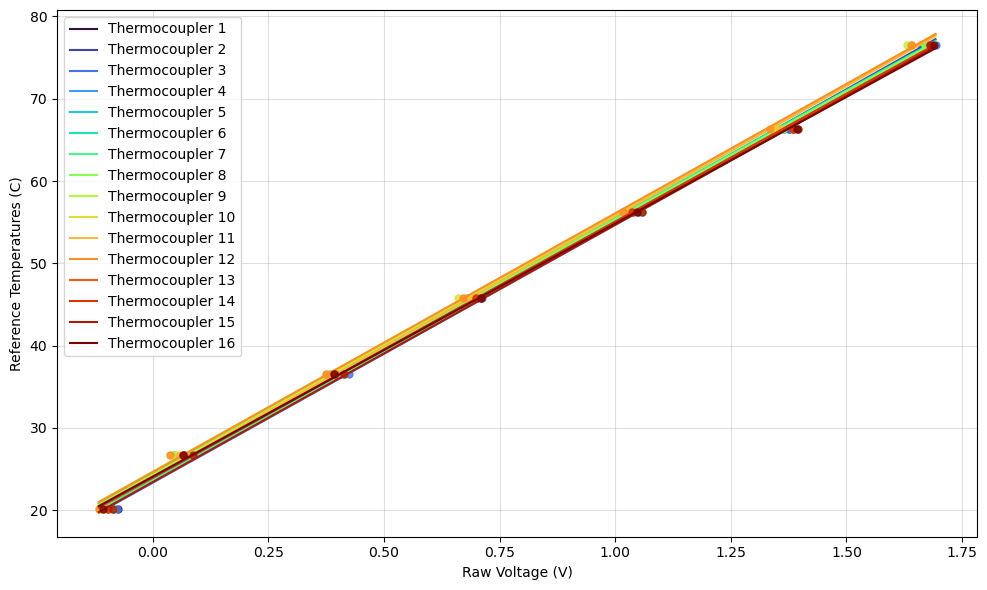

In [14]:
calib_plot(volts, temps, slopes, intercs)

## uniform measurements


In [15]:
def run(filename='uniform_run.csv', runtime_mins=75, interval_sec=60):
    steps=int((runtime_mins * 60)/interval_sec)
    data=[]

    print('Run start.')
    for step in range(steps):
        v_row=thermocouple_16loop()
        data.append(v_row)

        df=pd.DataFrame(data,columns=[f'TC_{i+1}' for i in range(16)])
        df.to_csv(filename,index=False)

        print(f'Step {step+1}/{steps} recorded.')
        time.sleep(interval_sec)

    return np.array(data)

In [17]:
uniform_test = run(filename='test_run.csv', runtime_mins=2, interval_sec=10)

Run start.
Step 1/12 recorded.
Step 2/12 recorded.
Step 3/12 recorded.
Step 4/12 recorded.
Step 5/12 recorded.
Step 6/12 recorded.
Step 7/12 recorded.
Step 8/12 recorded.
Step 9/12 recorded.
Step 10/12 recorded.
Step 11/12 recorded.
Step 12/12 recorded.


In [19]:
print(volt_to_C(uniform_test))

[[24.33917222 24.24547146 24.15658097 24.09117632 24.61167968 24.60704119
  23.80667185 24.14735667 26.11354071 24.89699526 24.26721735 24.19481446
  24.14679469 24.14679475 23.90993503 23.92928323]
 [24.33917222 24.24547146 24.15658097 24.09117632 24.29649131 24.28986495
  23.80667185 24.14735667 25.79019579 24.57678521 24.26721735 24.19481446
  24.14679469 24.14679475 23.90993503 23.92928323]
 [24.01818484 24.24547146 24.15658097 24.09117632 24.29649131 24.28986495
  23.80667185 24.14735667 25.79019579 24.57678521 24.26721735 23.87373103
  24.14679469 24.14679475 23.59062857 23.92928323]
 [24.33917222 24.24547146 24.15658097 24.09117632 24.29649131 24.28986495
  23.80667185 23.83008874 25.46685087 24.57678521 24.26721735 23.87373103
  24.14679469 24.14679475 23.59062857 23.92928323]
 [24.01818484 24.24547146 24.15658097 24.09117632 24.29649131 24.28986495
  23.80667185 23.83008874 25.79019579 24.57678521 24.26721735 23.87373103
  24.14679469 24.14679475 23.59062857 23.92928323]
 [24.

In [20]:
uniform_run = run(filename='uniform_run.csv', runtime_mins=75, interval_sec=60)

Run start.
Step 1/75 recorded.
Step 2/75 recorded.
Step 3/75 recorded.
Step 4/75 recorded.
Step 5/75 recorded.
Step 6/75 recorded.
Step 7/75 recorded.
Step 8/75 recorded.
Step 9/75 recorded.
Step 10/75 recorded.
Step 11/75 recorded.
Step 12/75 recorded.
Step 13/75 recorded.
Step 14/75 recorded.
Step 15/75 recorded.
Step 16/75 recorded.
Step 17/75 recorded.
Step 18/75 recorded.
Step 19/75 recorded.
Step 20/75 recorded.
Step 21/75 recorded.
Step 22/75 recorded.
Step 23/75 recorded.
Step 24/75 recorded.
Step 25/75 recorded.
Step 26/75 recorded.
Step 27/75 recorded.
Step 28/75 recorded.
Step 29/75 recorded.
Step 30/75 recorded.
Step 31/75 recorded.
Step 32/75 recorded.
Step 33/75 recorded.
Step 34/75 recorded.
Step 35/75 recorded.
Step 36/75 recorded.
Step 37/75 recorded.
Step 38/75 recorded.
Step 39/75 recorded.
Step 40/75 recorded.
Step 41/75 recorded.
Step 42/75 recorded.
Step 43/75 recorded.
Step 44/75 recorded.
Step 45/75 recorded.
Step 46/75 recorded.
Step 47/75 recorded.
Step 48/75 

In [22]:
print(np.round(volt_to_C(uniform_run),2))

[[ 24.34  24.25  23.84 ...  23.51  23.27  23.3 ]
 [ 24.34  24.25  24.16 ...  23.19  22.95  23.3 ]
 [ 24.66  24.57  24.16 ...  23.19  22.63  22.99]
 ...
 [122.88 112.74 103.92 ...  26.69  26.15  25.81]
 [122.56 112.42 103.92 ...  26.69  26.15  25.81]
 [122.88 112.74 103.92 ...  27.    26.15  25.81]]


In [25]:
np.shape(uniform_run)

(75, 16)

## non-uniform measurements

In [44]:
nonuniform_test = run(filename='nontest_run.csv', runtime_mins=1, interval_sec=10)
print(np.round(volt_to_C(nonuniform_test),2))

Run start.
Step 1/6 recorded.
Step 2/6 recorded.
Step 3/6 recorded.
Step 4/6 recorded.
Step 5/6 recorded.
Step 6/6 recorded.
[[32.04 31.35 30.56 29.85 32.49 41.1  34.29 37.79 31.29 38.99 34.29 31.26
  24.15 23.19 22.63 22.67]
 [32.04 31.35 30.56 29.85 33.12 42.05 35.24 38.42 32.58 41.23 35.26 32.22
  24.46 23.51 22.95 22.67]
 [32.36 31.35 30.88 30.17 33.75 42.37 35.88 39.06 32.9  40.91 35.91 32.86
  24.78 23.83 23.27 22.99]
 [32.36 31.67 30.88 30.49 34.38 43.32 36.51 40.01 33.23 40.27 36.23 33.19
  25.42 24.15 23.59 23.3 ]
 [32.36 32.   31.2  30.81 34.7  43.95 37.46 40.96 33.55 39.95 36.23 33.51
  25.42 24.46 23.59 23.62]
 [32.68 32.   31.2  30.81 35.33 44.91 38.1  41.6  33.87 40.27 36.55 33.83
  25.73 24.78 23.91 23.62]]


In [45]:
nonuniform_run = run(filename='nonuniform_run.csv', runtime_mins=75, interval_sec=60)
print(np.round(volt_to_C(nonuniform_run),2))

Run start.
Step 1/75 recorded.
Step 2/75 recorded.
Step 3/75 recorded.
Step 4/75 recorded.
Step 5/75 recorded.
Step 6/75 recorded.
Step 7/75 recorded.
Step 8/75 recorded.
Step 9/75 recorded.
Step 10/75 recorded.
Step 11/75 recorded.
Step 12/75 recorded.
Step 13/75 recorded.
Step 14/75 recorded.
Step 15/75 recorded.
Step 16/75 recorded.
Step 17/75 recorded.
Step 18/75 recorded.
Step 19/75 recorded.
Step 20/75 recorded.
Step 21/75 recorded.
Step 22/75 recorded.
Step 23/75 recorded.
Step 24/75 recorded.
Step 25/75 recorded.
Step 26/75 recorded.
Step 27/75 recorded.
Step 28/75 recorded.
Step 29/75 recorded.
Step 30/75 recorded.
Step 31/75 recorded.
Step 32/75 recorded.
Step 33/75 recorded.
Step 34/75 recorded.
Step 35/75 recorded.
Step 36/75 recorded.
Step 37/75 recorded.
Step 38/75 recorded.
Step 39/75 recorded.
Step 40/75 recorded.
Step 41/75 recorded.
Step 42/75 recorded.
Step 43/75 recorded.
Step 44/75 recorded.
Step 45/75 recorded.
Step 46/75 recorded.
Step 47/75 recorded.
Step 48/75 